# Explore the bundled SCD Edition recording

This notebook locates the example inside the installed package and loads it through the same data-loader code used by the GUI.

In [1]:
from pathlib import Path

from scd_app.examples import bundled_example_config, bundled_example_path
from scd_app.io.data_loader import load_field, load_layout

sample_path = bundled_example_path()
layout_path = Path("../src/scd_app/resources/loaders_configs/loader_mat.yaml").resolve()
if not layout_path.is_file():
    import scd_app

    layout_path = (
        Path(scd_app.__file__).parent / "resources/loaders_configs/loader_mat.yaml"
    )

layout = load_layout(layout_path)
config = bundled_example_config()
layout["fields"]["emg"]["path"] = config["emg_path"]
layout["fields"]["emg"]["orientation"] = config["emg_orientation"]
emg = load_field(sample_path, layout, "emg")
print(f"{sample_path.name}: {tuple(emg.shape)} samples x channels")
print(f"Sampling rate: {config['sampling_rate']} Hz")

emg.mat: (102401, 64) samples x channels
Sampling rate: 10240 Hz


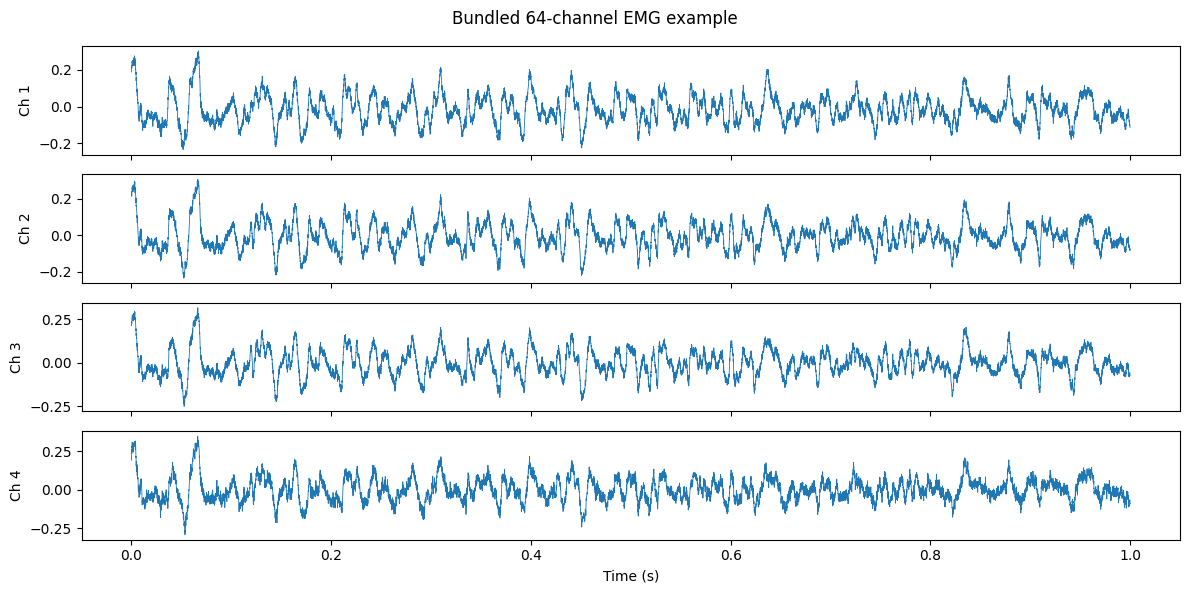

In [2]:
import matplotlib.pyplot as plt

fs = config["sampling_rate"]
seconds = 1
time = [index / fs for index in range(fs * seconds)]

fig, axes = plt.subplots(4, 1, figsize=(12, 6), sharex=True)
for channel, axis in enumerate(axes):
    trace = emg[: fs * seconds, channel].numpy()
    axis.plot(time, trace, linewidth=0.6)
    axis.set_ylabel(f"Ch {channel + 1}")
axes[-1].set_xlabel("Time (s)")
fig.suptitle("Bundled 64-channel EMG example")
fig.tight_layout()

## Continue in the GUI

Run `scd-edition --example`, click **Apply Configuration**, and follow the [quick-start](quickstart.md).